<a href="https://colab.research.google.com/github/fzkmdly/Strait_Hormuz_act/blob/main/2026_Strait_of_Hormuz_Crisis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install psycopg2-binary sqlalchemy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 30.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import psycopg2
from sqlalchemy import create_engine
import unittest
import seaborn as sns
import matplotlib.pyplot as plt

## Data Preparation

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("moaz1911/strait-of-hormuz-2026-the-great-decoupling")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'strait-of-hormuz-2026-the-great-decoupling' dataset.
Path to dataset files: /kaggle/input/strait-of-hormuz-2026-the-great-decoupling


In [ ]:
df = pd.read_csv('/kaggle/input/strait-of-hormuz-2026-the-great-decoupling/hormuz_trade_tier_continental_2026.csv')

df

,date,vessel_name,mmsi,flag,trade_tier,transit_status,toll_usd,rerouted,commodity,destination,...,insurance_cost_usd,days_delayed,extra_fuel_tonnes,reroute_penalty_usd,total_transit_cost_usd,naval_escort_status,estimated_cargo_value_usd,total_asset_value_at_risk_usd,continent,inflation_premium_per_unit
0,2026-03-01,MarchVessel_1,100000001,India,Privileged,Passed,0,No,Various,Global Port,...,40000,0,0,0,40000,Light (Cooperative),80000000,160000000,Asia,NaN
1,2026-03-01,MarchVessel_2,100000002,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,70000,0,0,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035000
2,2026-03-01,MarchVessel_3,100000003,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,70000,0,0,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035000
3,2026-03-02,MarchVessel_4,100000004,Greece,Taxed,Passed,2000000,No,Various,Global Port,...,1000000,0,0,0,3000000,NaN,80000000,160000000,Europe,NaN
4,2026-03-02,MarchVessel_5,100000005,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,70000,0,0,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1885,2026-05-31,Iron Carrier 15,386403601,UK,Blocked,Rerouted,0,Yes (Cape of Good Hope),Bulk Carrier,Mumbai,...,67500,12,480,607200,674700,NaN,50000000,95000000,Europe,NaN
1886,2026-05-31,Global Star 34,369408512,Iran,Privileged,Passed,0,No,Container Ship,Hidden/Private,...,55000,0,0,0,55000,Internal (IRGC Navy),150000000,260000000,Asia,3.666667
1887,2026-05-31,Red Spirit 36,559556395,Liberia,Taxed,Passed,2000000,No,LNG Carrier,Houston,...,2750000,0,0,0,4750000,NaN,200000000,420000000,Africa,1.397059
1888,2026-05-31,Eastern Titan 10,238114122,Russia,Privileged,Passed,0,No,Container Ship,Hidden/Private,...,55000,0,0,0,55000,Heavy (PLAN/RF Navy),150000000,260000000,Eurasia,3.666667


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1890 entries, 0 to 1889
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   date                           1890 non-null   object 
 1   vessel_name                    1890 non-null   object 
 2   mmsi                           1890 non-null   int64  
 3   flag                           1890 non-null   object 
 4   trade_tier                     1890 non-null   object 
 5   transit_status                 1890 non-null   object 
 6   toll_usd                       1890 non-null   int64  
 7   rerouted                       1890 non-null   object 
 8   commodity                      1890 non-null   object 
 9   destination                    1890 non-null   object 
 10  payment_rail                   1890 non-null   object 
 11  ship_hull_value_usd            1890 non-null   int64  
 12  insurance_premium_delta_pct    1890 non-null   f

In [ ]:
df.describe(include='all')

,date,vessel_name,mmsi,flag,trade_tier,transit_status,toll_usd,rerouted,commodity,destination,...,insurance_cost_usd,days_delayed,extra_fuel_tonnes,reroute_penalty_usd,total_transit_cost_usd,naval_escort_status,estimated_cargo_value_usd,total_asset_value_at_risk_usd,continent,inflation_premium_per_unit
count,1890,1890,1.890000e+03,1890,1890,1890,1.890000e+03,1890,1890,1890,...,1.890000e+03,1890.000000,1890.000000,1.890000e+03,1.890000e+03,679,1.890000e+03,1.890000e+03,1890,1391.000000
unique,92,337,NaN,17,3,3,NaN,2,6,8,...,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,6,NaN
top,2026-05-22,Eastern Carrier 13,NaN,Iran,Privileged,Passed,NaN,No,LNG Carrier,Hidden/Private,...,NaN,NaN,NaN,NaN,NaN,Heavy (PLAN/RF Navy),NaN,NaN,Asia,NaN
freq,36,22,NaN,253,676,1098,NaN,1214,458,558,...,NaN,NaN,NaN,NaN,NaN,255,NaN,NaN,1006,NaN
mean,NaN,NaN,4.136784e+08,NaN,NaN,NaN,4.465608e+05,NaN,NaN,NaN,...,4.790489e+05,4.292063,470.285714,6.113289e+05,1.536939e+06,NaN,1.610794e+08,2.896508e+08,NaN,35.101053
std,NaN,NaN,1.644222e+08,NaN,NaN,NaN,8.331100e+05,NaN,NaN,NaN,...,7.065673e+05,5.753300,711.964768,9.390808e+05,1.478589e+06,NaN,7.221446e+07,1.266159e+08,NaN,71.026366
min,NaN,NaN,1.000000e+08,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,...,2.250000e+04,0.000000,0.000000,0.000000e+00,2.250000e+04,NaN,5.000000e+07,9.500000e+07,NaN,0.032353
25%,NaN,NaN,3.020478e+08,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,...,7.000000e+04,0.000000,0.000000,0.000000e+00,7.000000e+04,NaN,8.000000e+07,1.600000e+08,NaN,0.035000
50%,NaN,NaN,4.007435e+08,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,...,1.650000e+05,0.000000,0.000000,0.000000e+00,1.100000e+06,NaN,2.000000e+08,3.800000e+08,NaN,0.879000
75%,NaN,NaN,5.584031e+08,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,...,5.625000e+05,12.000000,1200.000000,1.548000e+06,2.988000e+06,NaN,2.400000e+08,3.800000e+08,NaN,3.666667


In [ ]:
df['inflation_premium_per_unit'].mean()

np.float64(35.101053058175104)

In [ ]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0
naval_escort_status,1211
inflation_premium_per_unit,499


In [ ]:
less = missing_values[(missing_values < 1400) & (missing_values > 0)].index
over = missing_values[missing_values >= 1400].index

df[less]

,naval_escort_status,inflation_premium_per_unit
0,Light (Cooperative),NaN
1,Internal (IRGC Navy),0.035000
2,Internal (IRGC Navy),0.035000
3,NaN,NaN
4,Internal (IRGC Navy),0.035000
...,...,...
1885,NaN,NaN
1886,Internal (IRGC Navy),3.666667
1887,NaN,1.397059
1888,Heavy (PLAN/RF Navy),3.666667


In [ ]:
#fitur kategori
numeric_features = df.select_dtypes(include=['number']).columns
string_features = df.select_dtypes(include=['object']).columns

string_features

Index(['date', 'vessel_name', 'flag', 'trade_tier', 'transit_status',
       'rerouted', 'commodity', 'destination', 'payment_rail',
       'naval_escort_status', 'continent'],
      dtype='object')

In [ ]:
#Naval escort missing value

naval_escort = df[less].select_dtypes(include=['object']).columns

df[naval_escort] = df[naval_escort].fillna('Unescorted/Unknown')

df[less]

,naval_escort_status,inflation_premium_per_unit
0,Light (Cooperative),NaN
1,Internal (IRGC Navy),0.035000
2,Internal (IRGC Navy),0.035000
3,Unescorted/Unknown,NaN
4,Internal (IRGC Navy),0.035000
...,...,...
1885,Unescorted/Unknown,NaN
1886,Internal (IRGC Navy),3.666667
1887,Unescorted/Unknown,1.397059
1888,Heavy (PLAN/RF Navy),3.666667


In [ ]:
#Inflation_premium missing value

inflation_premium = df[less].select_dtypes(include=['float64']).columns

df[inflation_premium] = df[inflation_premium].fillna(df[inflation_premium].median())

df[less]

,naval_escort_status,inflation_premium_per_unit
0,Light (Cooperative),0.879000
1,Internal (IRGC Navy),0.035000
2,Internal (IRGC Navy),0.035000
3,Unescorted/Unknown,0.879000
4,Internal (IRGC Navy),0.035000
...,...,...
1885,Unescorted/Unknown,0.879000
1886,Internal (IRGC Navy),3.666667
1887,Unescorted/Unknown,1.397059
1888,Heavy (PLAN/RF Navy),3.666667


In [ ]:
df

,date,vessel_name,mmsi,flag,trade_tier,transit_status,toll_usd,rerouted,commodity,destination,...,insurance_cost_usd,days_delayed,extra_fuel_tonnes,reroute_penalty_usd,total_transit_cost_usd,naval_escort_status,estimated_cargo_value_usd,total_asset_value_at_risk_usd,continent,inflation_premium_per_unit
0,2026-03-01,MarchVessel_1,100000001,India,Privileged,Passed,0,No,Various,Global Port,...,40000,0,0,0,40000,Light (Cooperative),80000000,160000000,Asia,0.879000
1,2026-03-01,MarchVessel_2,100000002,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,70000,0,0,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035000
2,2026-03-01,MarchVessel_3,100000003,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,70000,0,0,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035000
3,2026-03-02,MarchVessel_4,100000004,Greece,Taxed,Passed,2000000,No,Various,Global Port,...,1000000,0,0,0,3000000,Unescorted/Unknown,80000000,160000000,Europe,0.879000
4,2026-03-02,MarchVessel_5,100000005,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,70000,0,0,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1885,2026-05-31,Iron Carrier 15,386403601,UK,Blocked,Rerouted,0,Yes (Cape of Good Hope),Bulk Carrier,Mumbai,...,67500,12,480,607200,674700,Unescorted/Unknown,50000000,95000000,Europe,0.879000
1886,2026-05-31,Global Star 34,369408512,Iran,Privileged,Passed,0,No,Container Ship,Hidden/Private,...,55000,0,0,0,55000,Internal (IRGC Navy),150000000,260000000,Asia,3.666667
1887,2026-05-31,Red Spirit 36,559556395,Liberia,Taxed,Passed,2000000,No,LNG Carrier,Houston,...,2750000,0,0,0,4750000,Unescorted/Unknown,200000000,420000000,Africa,1.397059
1888,2026-05-31,Eastern Titan 10,238114122,Russia,Privileged,Passed,0,No,Container Ship,Hidden/Private,...,55000,0,0,0,55000,Heavy (PLAN/RF Navy),150000000,260000000,Eurasia,3.666667


In [ ]:
if df.isnull().sum().sum() > 0:
  df.dropna(inplace=True)
else:
  print("Tidak ada data yang kosong")

df.isnull().sum()

Tidak ada data yang kosong


,0
date,0
vessel_name,0
mmsi,0
flag,0
trade_tier,0
transit_status,0
toll_usd,0
rerouted,0
commodity,0
destination,0


In [ ]:
if df.duplicated().sum() > 0:
  df.drop_duplicates(inplace=True)
else:
  print("Tidak ada data duplikat")

df.duplicated().sum()

Tidak ada data duplikat


np.int64(0)

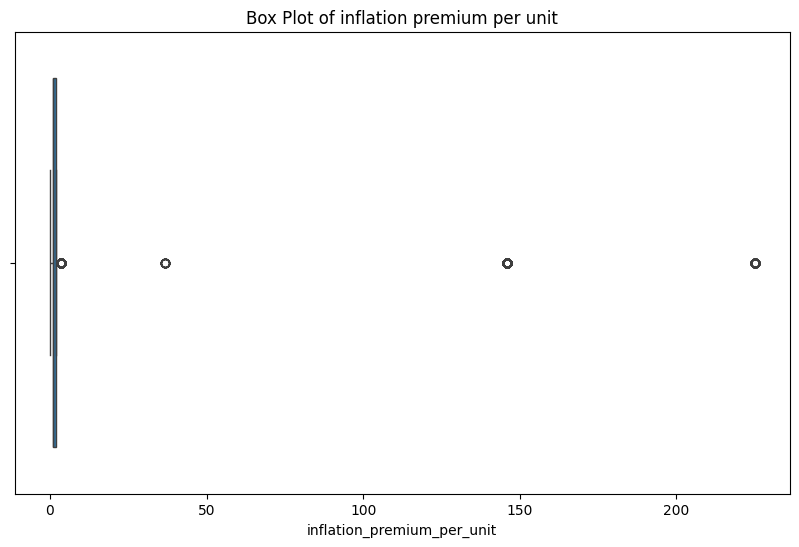

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['inflation_premium_per_unit'])
plt.title('Box Plot of inflation premium per unit')
plt.show()

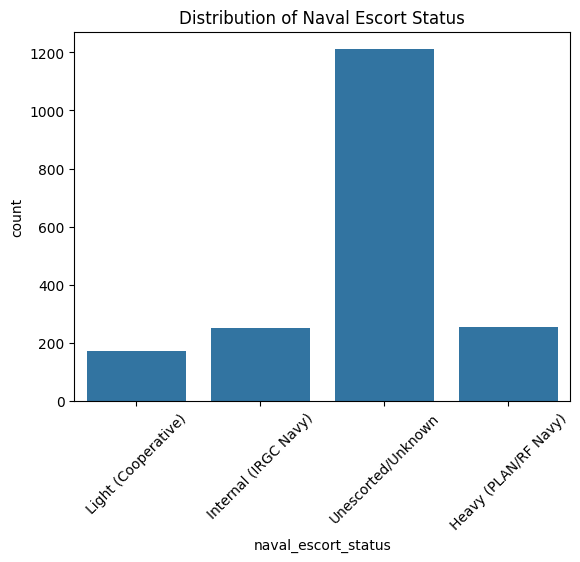

In [ ]:
sns.countplot(data=df, x='naval_escort_status')
plt.xticks(rotation=45)
plt.title('Distribution of Naval Escort Status')
plt.show()

In [ ]:
kapal_mahal = df[df['inflation_premium_per_unit'] > 100]

# 2. Lihat apa kesamaan dari kapal-kapal mahal ini
print("Status Pengawalan Kapal Mahal:")
print(kapal_mahal['naval_escort_status'].value_counts())

print("\nTujuan/Rute Kapal Mahal:")
print(kapal_mahal['destination'].value_counts())

Status Pengawalan Kapal Mahal:
naval_escort_status
Unescorted/Unknown    267
Name: count, dtype: int64

Tujuan/Rute Kapal Mahal:
destination
Houston      67
Rotterdam    57
Mumbai       54
Ningbo       46
Singapore    43
Name: count, dtype: int64


In [ ]:
# Label Encoding

# urutan_escort = {
#     'Unescorted/Unknown' : 0,
#     'Light (Cooperative)': 1,
#     'Internal (IRGC Navy)': 2,
#     'Heavy (PLAN/RF Navy)': 3
# }

urutan_escort = {
    'Unescorted/Unknown' : 3,
    'Light (Cooperative)': 2,
    'Internal (IRGC Navy)': 1,
    'Heavy (PLAN/RF Navy)': 0
}


# Menerapkan urutan ke kolom
df['naval_escort_status_encoded'] = df['naval_escort_status'].map(urutan_escort)
df['commodity_encoded'] = df['commodity'].astype('category').cat.codes
df['destination_encoded'] = df['destination'].astype('category').cat.codes

df

,date,vessel_name,mmsi,flag,trade_tier,transit_status,toll_usd,rerouted,commodity,destination,...,reroute_penalty_usd,total_transit_cost_usd,naval_escort_status,estimated_cargo_value_usd,total_asset_value_at_risk_usd,continent,inflation_premium_per_unit,naval_escort_status_encoded,commodity_encoded,destination_encoded
0,2026-03-01,MarchVessel_1,100000001,India,Privileged,Passed,0,No,Various,Global Port,...,0,40000,Light (Cooperative),80000000,160000000,Asia,0.879000,2,5,0
1,2026-03-01,MarchVessel_2,100000002,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035000,1,2,1
2,2026-03-01,MarchVessel_3,100000003,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035000,1,2,1
3,2026-03-02,MarchVessel_4,100000004,Greece,Taxed,Passed,2000000,No,Various,Global Port,...,0,3000000,Unescorted/Unknown,80000000,160000000,Europe,0.879000,3,5,0
4,2026-03-02,MarchVessel_5,100000005,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035000,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1885,2026-05-31,Iron Carrier 15,386403601,UK,Blocked,Rerouted,0,Yes (Cape of Good Hope),Bulk Carrier,Mumbai,...,607200,674700,Unescorted/Unknown,50000000,95000000,Europe,0.879000,3,0,4
1886,2026-05-31,Global Star 34,369408512,Iran,Privileged,Passed,0,No,Container Ship,Hidden/Private,...,0,55000,Internal (IRGC Navy),150000000,260000000,Asia,3.666667,1,1,2
1887,2026-05-31,Red Spirit 36,559556395,Liberia,Taxed,Passed,2000000,No,LNG Carrier,Houston,...,0,4750000,Unescorted/Unknown,200000000,420000000,Africa,1.397059,3,4,3
1888,2026-05-31,Eastern Titan 10,238114122,Russia,Privileged,Passed,0,No,Container Ship,Hidden/Private,...,0,55000,Heavy (PLAN/RF Navy),150000000,260000000,Eurasia,3.666667,0,1,2


In [ ]:
# Normalize
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# test = scaler.fit_transform(df[['inflation_premium_per_unit']])
# test

Text(0.5, 1.0, 'Histogram Setelah Standardisasi')

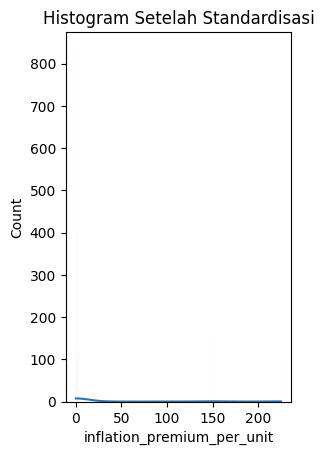

In [ ]:
plt.subplot(1, 2, 2)
sns.histplot(df['inflation_premium_per_unit'], kde=True)
plt.title("Histogram Setelah Standardisasi")

In [ ]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
}).sort_values(by='Missing Values', ascending=False)

missing_data[missing_data['Missing Values'] > 0]

,Missing Values,Percentage


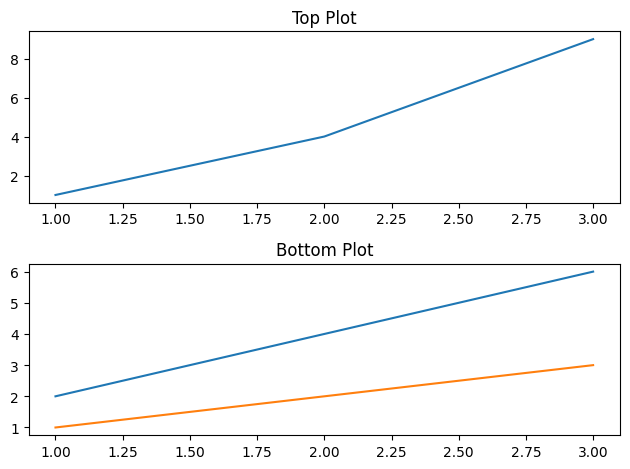

In [ ]:
# 2 rows, 1 column, 1st plot
plt.subplot(2, 1, 1)
plt.plot([1, 2, 3], [1, 4, 9])
plt.title("Top Plot")

plt.subplot(2, 1, 2)
plt.plot([1, 2, 3], [2, 4, 6])
plt.title("Center Plot")

# 2 rows, 1 column, 2nd plot
plt.subplot(2, 1, 2)
plt.plot([1, 2, 3], [1, 2, 3])
plt.title("Bottom Plot")

plt.tight_layout() # Fixes overlapping labels
plt.show()

# **Explanatory Data Analysist**

Text(0.5, 1.0, 'Premi Tertinggi Berdasarkan Commodity')

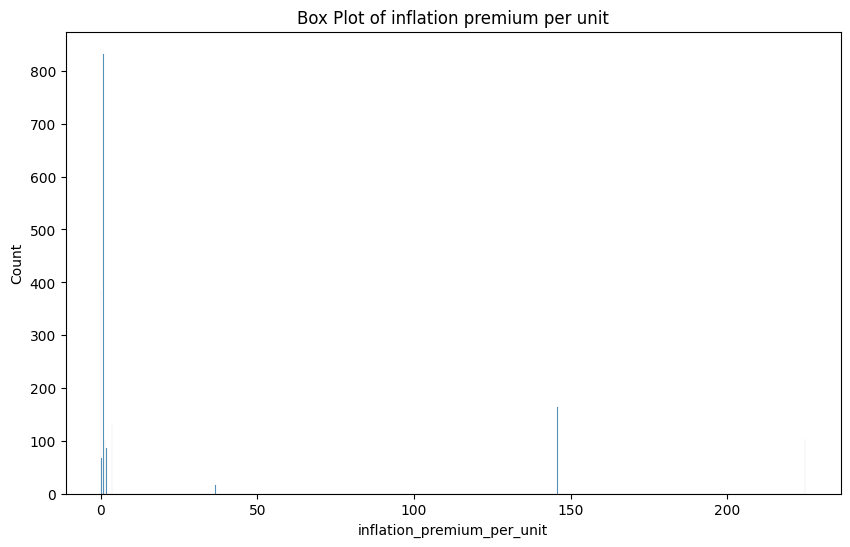

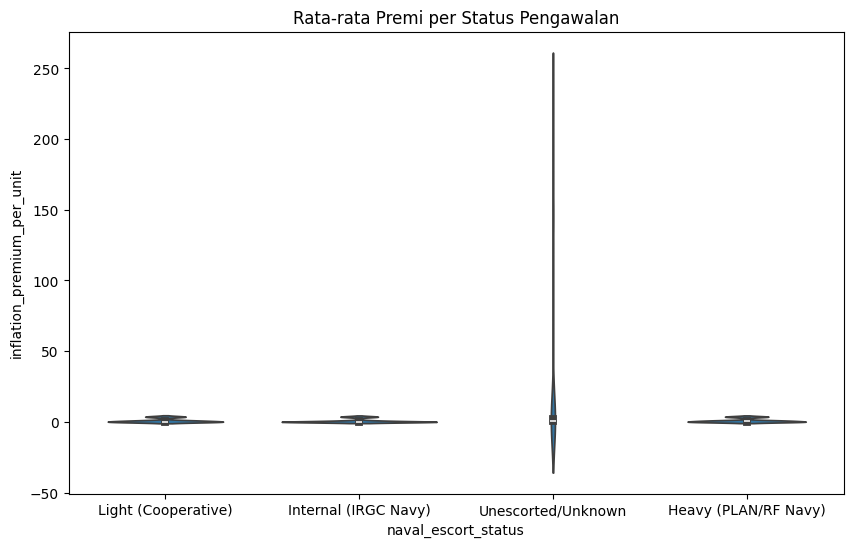

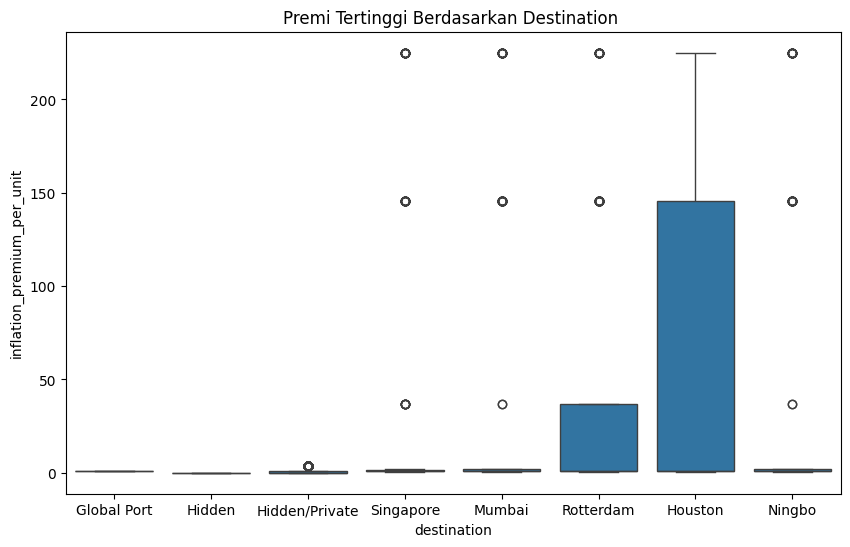

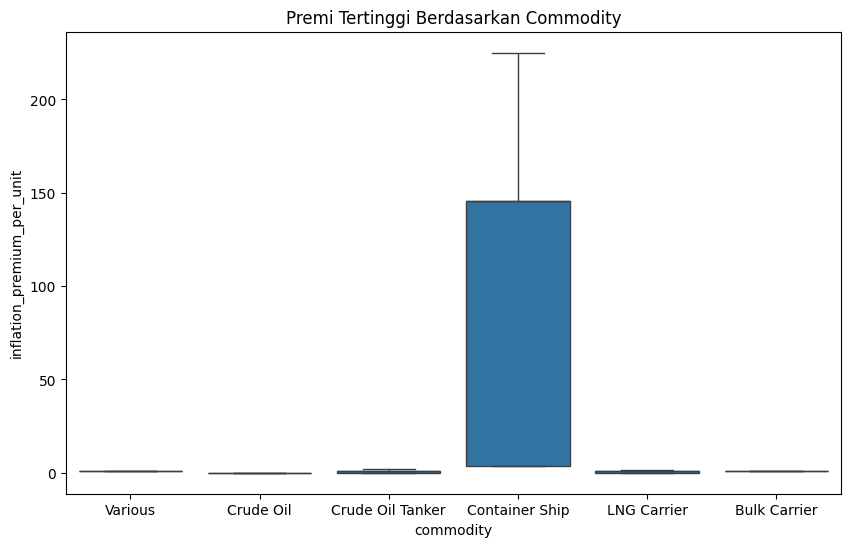

In [ ]:
#Inflasi premium setiap unit

plt.figure(figsize=(10, 6))
sns.histplot(x=df['inflation_premium_per_unit'])
plt.title('Box Plot of inflation premium per unit')

# Rata-rata Premi per Status Pengawalan
plt.figure(figsize=(10, 6))
sns.violinplot(x='naval_escort_status', y='inflation_premium_per_unit', data=df)
plt.title('Rata-rata Premi per Status Pengawalan')

# Premi tertinggi berdasarkan destination
plt.figure(figsize=(10, 6))
sns.boxplot(x='destination', y='inflation_premium_per_unit', data=df)
plt.title('Premi Tertinggi Berdasarkan Destination ')

#Premi tertinggi berdasarkan commodity
plt.figure(figsize=(10, 6))
sns.boxplot(x='commodity', y='inflation_premium_per_unit', data=df)
plt.title('Premi Tertinggi Berdasarkan Commodity')



1.   **Box Plot of inflation premium per unit**

Distribusi data bersifat 'Zero-Inflated' dan sangat condong ke kanan (Right-Skewed). Ini mengindikasikan bahwa secara umum (mayoritas), pelayaran maritim beroperasi dalam kondisi aman tanpa premi inflasi tambahan. Namun, terdapat segelintir pelayaran (ekor kanan) yang dikenakan premi ekstrem, menandakan adanya anomali risiko tinggi yang harus diselidiki.

2.   **Rata-rata Premi per Status Pengawalan**

Analisis Violin Plot menemukan 'Smoking Gun' (akar masalah). Ketiadaan pengawalan militer (Unescorted) berkorelasi absolut dengan lonjakan premi inflasi. Kapal yang dikawal, entah oleh angkatan laut internal maupun kooperatif, terbukti menekan angka premi kembali ke titik nol. Risiko keamanan adalah pendorong biaya utama.

3.   **Premi Tertinggi Berdasarkan Destination**

Rute pelayaran menentukan baseline risiko. Pelabuhan seperti Houston dan Rotterdam tidak hanya memiliki kasus ekstrem, tetapi secara median memang memiliki standar premi inflasi yang jauh lebih tinggi dibandingkan pelabuhan global lainnya. Hal ini kemungkinan dipengaruhi oleh jarak tempuh lintas benua dan regulasi asuransi rute spesifik tersebut.

4. **Premi tertinggi berdasarkan Komoditas**

Analisis komoditas mengungkap segmentasi risiko yang absolut. Lonjakan premi inflasi secara eksklusif hanya dibebankan pada Kapal Kontainer (Container Ship). Sementara armada lain seperti kapal tanker minyak atau gas beroperasi dengan premi standar, kapal kontainer menanggung seluruh beban risiko ekstrem dalam dataset ini.


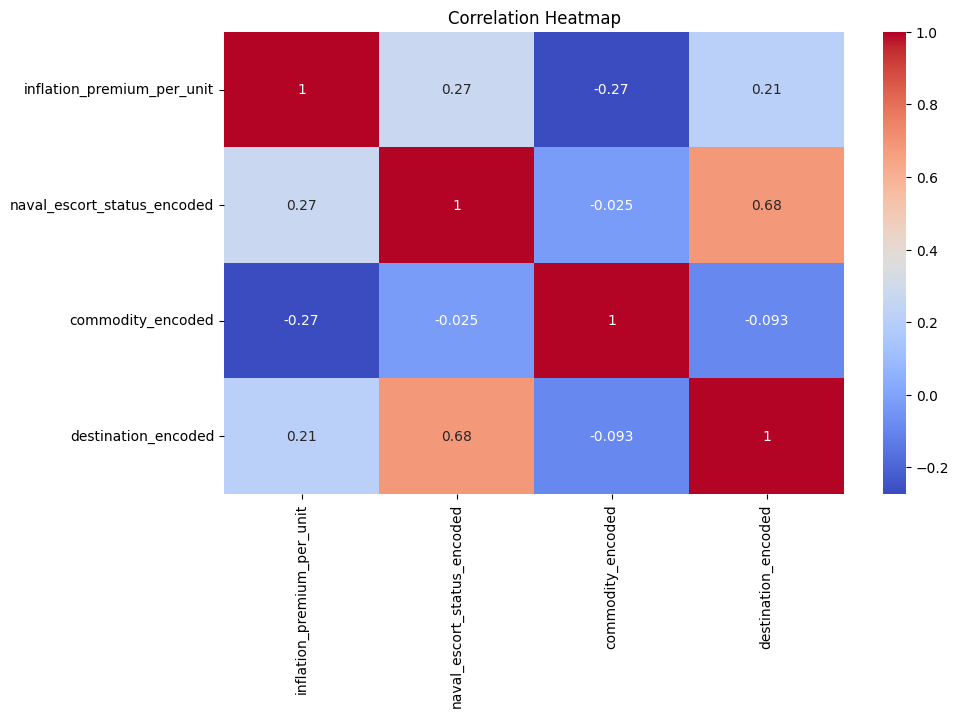

In [ ]:
#Korelasi

plt.figure(figsize=(10, 6))
sns.heatmap(df[['inflation_premium_per_unit', 'naval_escort_status_encoded', 'commodity_encoded', 'destination_encoded']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Kesimpulan :**

Dari heatmap ini, kita bisa menyimpulkan bahwa semua fitur yang kita siapkan memiliki korelasi yang valid terhadap harga premi. Selain itu, kita menemukan bahwa rute tujuan sangat mendikte status pengawalan kapal (korelasi 0.68). Datanya sudah terbukti bersih, logis, dan siap untuk dimasukkan ke algoritma Random Forest

**Pahami Skala Warna (Legenda di Kanan)**
Ini adalah "kunci inggris"-nya. Perhatikan palet warna di sebelah kanan grafismu:

1. Merah Peat (Mendekati 1.0): Hubungan searah yang sangat kuat.
2. Biru Pekat (Mendekati -1.0): Hubungan terbalik yang sangat kuat.
3. Warna Pucat/Putih (Mendekati 0.0): Tidak ada hubungan sama sekali (saling cuek)

# Data Splitting

In [ ]:
import sklearn

In [ ]:
df

,date,vessel_name,mmsi,flag,trade_tier,transit_status,toll_usd,rerouted,commodity,destination,...,reroute_penalty_usd,total_transit_cost_usd,naval_escort_status,estimated_cargo_value_usd,total_asset_value_at_risk_usd,continent,inflation_premium_per_unit,naval_escort_status_encoded,commodity_encoded,destination_encoded
0,2026-03-01,MarchVessel_1,100000001,India,Privileged,Passed,0,No,Various,Global Port,...,0,40000,Light (Cooperative),80000000,160000000,Asia,0.879000,2,5,0
1,2026-03-01,MarchVessel_2,100000002,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035000,1,2,1
2,2026-03-01,MarchVessel_3,100000003,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035000,1,2,1
3,2026-03-02,MarchVessel_4,100000004,Greece,Taxed,Passed,2000000,No,Various,Global Port,...,0,3000000,Unescorted/Unknown,80000000,160000000,Europe,0.879000,3,5,0
4,2026-03-02,MarchVessel_5,100000005,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035000,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1885,2026-05-31,Iron Carrier 15,386403601,UK,Blocked,Rerouted,0,Yes (Cape of Good Hope),Bulk Carrier,Mumbai,...,607200,674700,Unescorted/Unknown,50000000,95000000,Europe,0.879000,3,0,4
1886,2026-05-31,Global Star 34,369408512,Iran,Privileged,Passed,0,No,Container Ship,Hidden/Private,...,0,55000,Internal (IRGC Navy),150000000,260000000,Asia,3.666667,1,1,2
1887,2026-05-31,Red Spirit 36,559556395,Liberia,Taxed,Passed,2000000,No,LNG Carrier,Houston,...,0,4750000,Unescorted/Unknown,200000000,420000000,Africa,1.397059,3,4,3
1888,2026-05-31,Eastern Titan 10,238114122,Russia,Privileged,Passed,0,No,Container Ship,Hidden/Private,...,0,55000,Heavy (PLAN/RF Navy),150000000,260000000,Eurasia,3.666667,0,1,2


In [ ]:
x = df.drop(['inflation_premium_per_unit', 'destination', 'commodity', 'naval_escort_status'], axis=1)
y = df['inflation_premium_per_unit']

y

,inflation_premium_per_unit
0,0.879000
1,0.035000
2,0.035000
3,0.879000
4,0.035000
...,...
1885,0.879000
1886,3.666667
1887,1.397059
1888,3.666667


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Identify and drop non-numerical columns from X
# These include the original object columns that are not encoded or are not useful as features directly.
columns_to_drop = [
    'inflation_premium_per_unit',  # Target variable
    'date',                        # Object type, not directly usable by XGBoost
    'vessel_name',                 # Object type, not directly usable by XGBoost
    'flag',                        # Object type, not directly usable by XGBoost
    'trade_tier',                  # Object type, not directly usable by XGBoost
    'transit_status',              # Object type, not directly usable by XGBoost
    'rerouted',                    # Object type, not directly usable by XGBoost
    'commodity',                   # Original object column, now encoded, so drop original
    'destination',                 # Original object column, now encoded, so drop original
    'payment_rail',                # Object type, not directly usable by XGBoost
    'naval_escort_status',         # Original object column, now encoded, so drop original
    'continent'                    # Object type, not directly usable by XGBoost
]

X = df.drop(columns=columns_to_drop)
y = df['inflation_premium_per_unit']

# 2. Belah data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("Jumlah data: ",len(x))
# menghitung panjang/jumlah data pada x_train
print("Jumlah data latih: ",len(X_train))
# menghitung panjang/jumlah data pada x_test
print("Jumlah data test: ",len(X_test))

Jumlah data:  1890
Jumlah data latih:  1512
Jumlah data test:  378


In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1890 entries, 0 to 1889
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   date                           1890 non-null   object 
 1   vessel_name                    1890 non-null   object 
 2   mmsi                           1890 non-null   int64  
 3   flag                           1890 non-null   object 
 4   trade_tier                     1890 non-null   object 
 5   transit_status                 1890 non-null   object 
 6   toll_usd                       1890 non-null   int64  
 7   rerouted                       1890 non-null   object 
 8   payment_rail                   1890 non-null   object 
 9   ship_hull_value_usd            1890 non-null   int64  
 10  insurance_premium_delta_pct    1890 non-null   float64
 11  insurance_cost_usd             1890 non-null   int64  
 12  days_delayed                   1890 non-null   i

In [ ]:
# max_depth=5 mencegah model terlalu menghafal (overfitting)
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# 4. Latih Modelnya!
model_xgb.fit(X_train, y_train)

# 5. Lakukan Prediksi
prediksi_xgb = model_xgb.predict(X_test)

# 6. Lihat Hasil Ujiannya
print(f"Akurasi XGBoost (R2 Score)  : {r2_score(y_test, prediksi_xgb):.4f}")
print(f"Rata-rata Kesalahan (MAE)   : {mean_absolute_error(y_test, prediksi_xgb):.4f}")

Akurasi XGBoost (R2 Score)  : 1.0000
Rata-rata Kesalahan (MAE)   : 0.0013


/tmp/ipykernel_9242/3179026940.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fitur_df, x='Tingkat Kepentingan', y='Fitur', palette='viridis')


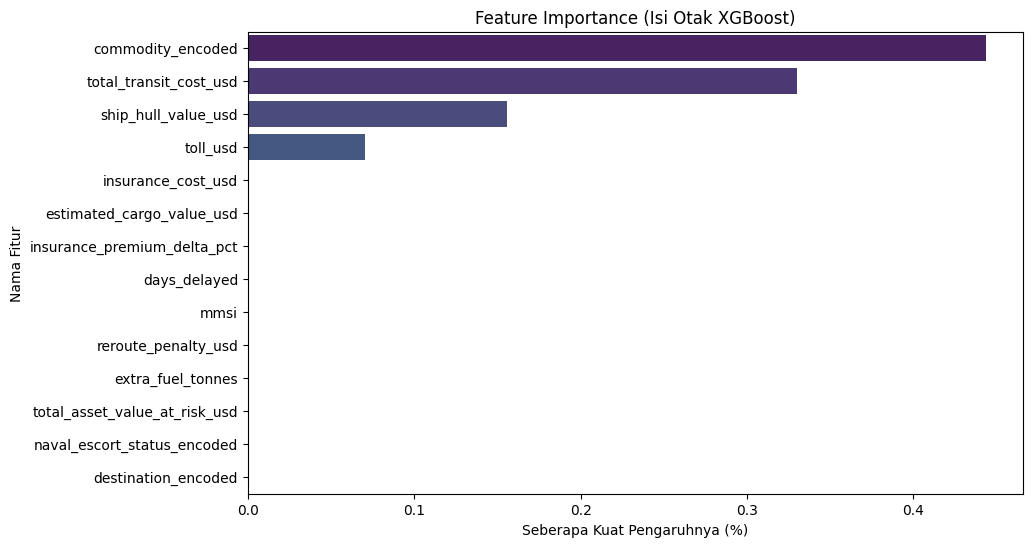

In [ ]:
# Mengambil nilai "seberapa penting" sebuah fitur dari otak XGBoost
importances = model_xgb.feature_importances_

# Membuat dataframe agar rapi
fitur_df = pd.DataFrame({
    'Fitur': X.columns,
    'Tingkat Kepentingan': importances
})

# Mengurutkan dari yang paling penting
fitur_df = fitur_df.sort_values(by='Tingkat Kepentingan', ascending=False)

# Membuat visualisasi bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=fitur_df, x='Tingkat Kepentingan', y='Fitur', palette='viridis')
plt.title('Feature Importance (Isi Otak XGBoost)')
plt.xlabel('Seberapa Kuat Pengaruhnya (%)')
plt.ylabel('Nama Fitur')
plt.show()

# -

1. Pemenang Utama: commodity_encoded

Ternyata, dugaan kita di akhir sesi EDA terbukti benar! Jenis muatan (terutama Kapal Kontainer) adalah kunci utama penentu harga. XGBoost menempatkannya sebagai faktor paling penting (sekitar 45% pengaruhnya).

2. Misteri "Data Leakage" (Kebocoran Data)

Coba lihat juara ke-2, ke-3, dan ke-4:
  - total_transit_cost_usd (Total Biaya Transit)
  - ship_hull_value_usd (Nilai Lambung Kapal)
  - toll_usd (Biaya Tol)

  Ini adalah "Tersangka" yang membuat modelmu mendapat skor 1.0000. Di dunia Machine Learning, ini disebut Data Leakage (Kebocoran Data).
Logikanya begini: total_transit_cost_usd kemungkinan besar adalah hasil penjumlahan matematika dari biaya-biaya lain, termasuk inflation_premium_per_unit.

Jadi, menyuruh model menebak "Berapa Preminya?" tapi kamu memberi tahu "Total Biayanya", itu ibarat menyuruh anak SD menebak nilai X dalam soal: 100 = 80 + X.
XGBoost terlalu pintar; ia langsung menyadari rumus matematika ini, memecahkannya dengan akurasi 100%, dan...

3. Kenapa naval_escort Tiba-tiba Jadi 0%?

Di grafik ini, naval_escort_status_encoded dan destination_encoded terdampar di paling bawah (0%). Padahal di EDA, kita tahu mereka sangat penting!

Kenapa XGBoost mengabaikannya? Karena sifat algoritma Decision Tree. Jika XGBoost sudah bisa mendapatkan jawaban sempurna (100%) lewat jalur pintas hitung-hitungan matematika (Total Biaya - Biaya Lain = Premi), ia akan menjadi "malas". Ia merasa tidak perlu lagi mengecek status pengawalan atau rute pelabuhan karena jawabannya sudah ketemu lewat kolom biaya!

In [ ]:
from sklearn.metrics import mean_squared_error

# 1. Hapus target dan HAPUS JUGA kolom-kolom finansial yang menyebabkan "Data Leakage"
kolom_bocor = ['inflation_premium_per_unit', 'total_transit_cost_usd', 'ship_hull_value_usd', 'toll_usd', 'insurance_cost_usd', 'total_asset_value_at_risk_usd', 'reroute_penalty_usd', 'estimated_cargo_value_usd', 'insurance_premium_delta_pct']

# Combine all columns that need to be dropped from both lists, ensuring unique column names
all_columns_to_exclude = list(set(kolom_bocor + columns_to_drop))

X_jujur = df.drop(columns=all_columns_to_exclude)
y_jujur = df['inflation_premium_per_unit']

# 2. Split data ulang
X_train, X_test, y_train, y_test = train_test_split(X_jujur, y_jujur, test_size=0.2, random_state=42)

# 3. Latih model ulang
model_xgb_jujur = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_xgb_jujur.fit(X_train, y_train)

# 4. Evaluasi ulang
prediksi_jujur = model_xgb_jujur.predict(X_test)

print(f"Akurasi Model 'Jujur' (R2 Score) : {r2_score(y_test, prediksi_jujur):.4f}")
print(f"Rata-rata Kesalahan (MAE)       : {mean_absolute_error(y_test, prediksi_jujur):.4f}")
print(f"Rata-rata MSE                   : {np.sqrt(mean_squared_error(y_test, prediksi_jujur)):.4f}")

Akurasi Model 'Jujur' (R2 Score) : 0.9063
Rata-rata Kesalahan (MAE)       : 4.2402
Rata-rata MSE                   : 20.5864


/tmp/ipykernel_9242/1392075146.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fitur_df_jujur, x='Tingkat Kepentingan', y='Fitur', palette='viridis')


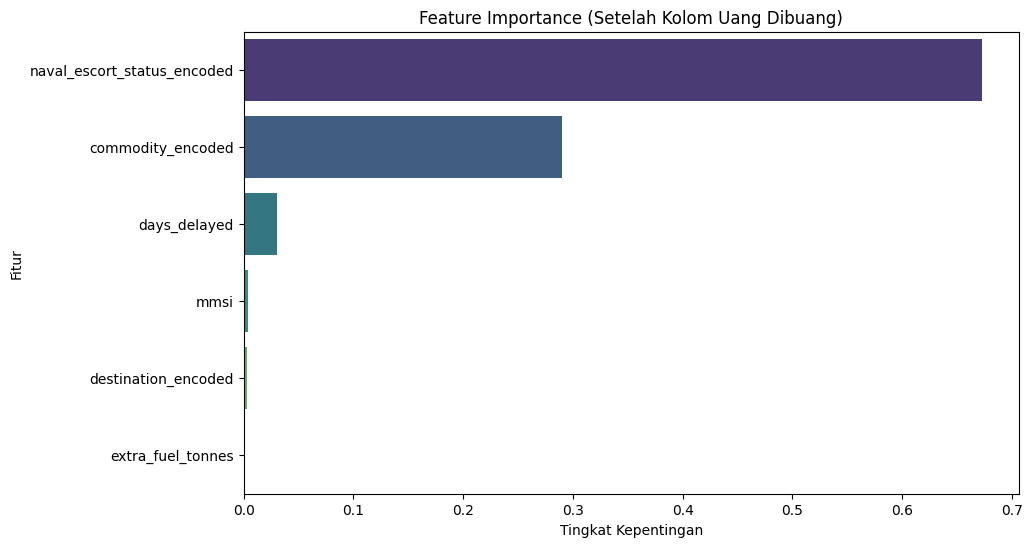

In [ ]:
importances_jujur = model_xgb_jujur.feature_importances_

fitur_df_jujur = pd.DataFrame({
    'Fitur': X_jujur.columns,
    'Tingkat Kepentingan': importances_jujur
}).sort_values(by='Tingkat Kepentingan', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fitur_df_jujur, x='Tingkat Kepentingan', y='Fitur', palette='viridis')
plt.title('Feature Importance (Setelah Kolom Uang Dibuang)')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

Model_RandomForest = RandomForestRegressor(n_estimators=100, random_state=42)
Model_RandomForest.fit(X_jujur, y_jujur)

# Make predictions with the trained RandomForestRegressor model
y_pred_rf = Model_RandomForest.predict(X_test)

print(f"Akurasi Model 'Jujur' (R2 Score) : {r2_score(y_test, y_pred_rf):.4f}")
print(f"Rata-rata Kesalahan (MAE)       : {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"Rata-rata MSE                   : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")

Akurasi Model 'Jujur' (R2 Score) : 0.9867
Rata-rata Kesalahan (MAE)       : 1.2880
Rata-rata MSE                   : 7.7577


/tmp/ipykernel_9242/2681090015.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fitur_df_jujur, x='Tingkat Kepentingan', y='Fitur', palette='viridis')


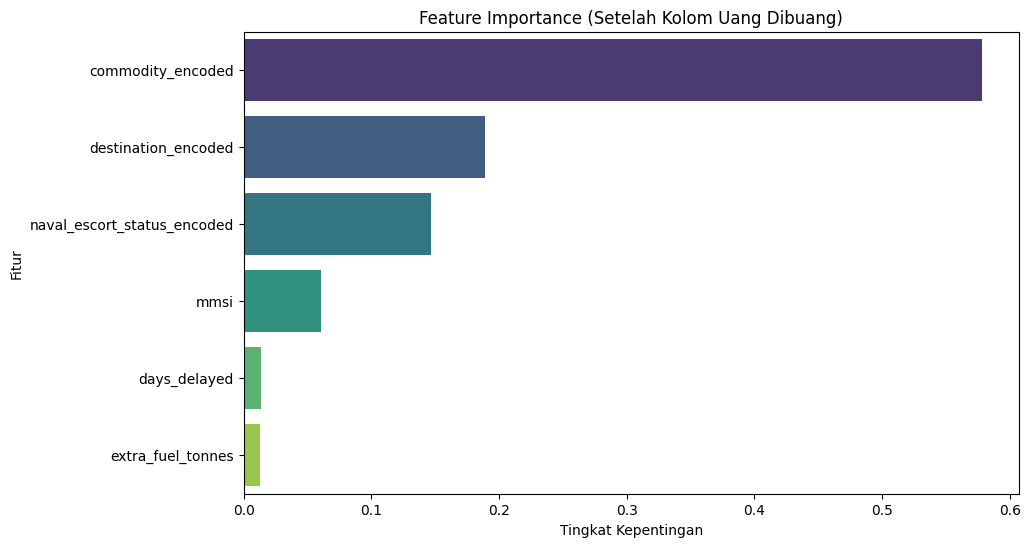

In [ ]:
randomforest_importance = Model_RandomForest.feature_importances_

fitur_df_jujur = pd.DataFrame({
    'Fitur': X_jujur.columns,
    'Tingkat Kepentingan': randomforest_importance
}).sort_values(by='Tingkat Kepentingan', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fitur_df_jujur, x='Tingkat Kepentingan', y='Fitur', palette='viridis')
plt.title('Feature Importance (Setelah Kolom Uang Dibuang)')
plt.show()

# Simpan Model

In [ ]:
import joblib
import pickle

joblib.dump(model_xgb_jujur, 'model_xgb_jujur.pkl')
with open('randomForest_model.pkl', 'wb') as file:
    pickle.dump(Model_RandomForest, file)